# linear-regressions-manually
Goal is to Implement linear regression manually.

## Imports and global variables

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(44)
sample_size = 1000  # number of samples

## Load Synthetic Dataset

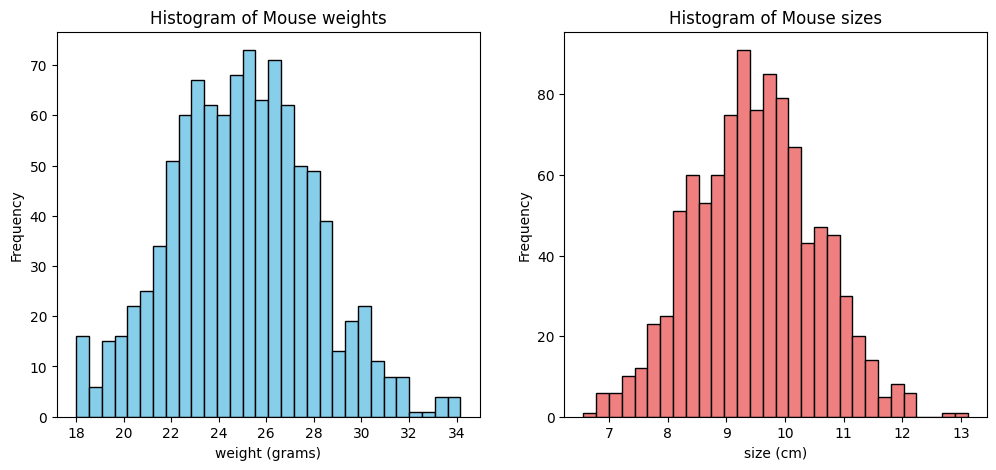

In [2]:
# Realistic adult mouse measurements
weight = np.random.normal(loc=25, scale=3, size=sample_size)  # 25g average
weight = np.clip(weight, 18, 35)

# True relationship: ~0.3 cm per gram (realistic proportion)
true_slope = 0.3
true_intercept = 2

noise = np.random.normal(loc=0, scale=0.5, size=sample_size)
size = true_slope * weight + true_intercept + noise

# Plot histogram of mouse weights and mouse sizes
fig, axs = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)
axs[0, 0].hist(weight, bins=30, color="skyblue", edgecolor="black")
axs[0, 0].set_xlabel("weight (grams)")
axs[0, 0].set_ylabel("Frequency")
axs[0, 0].set_title("Histogram of Mouse weights")

axs[0, 1].hist(size, bins=30, color="lightcoral", edgecolor="black")
axs[0, 1].set_xlabel("size (cm)")
axs[0, 1].set_ylabel("Frequency")
axs[0, 1].set_title("Histogram of Mouse sizes")
plt.show()

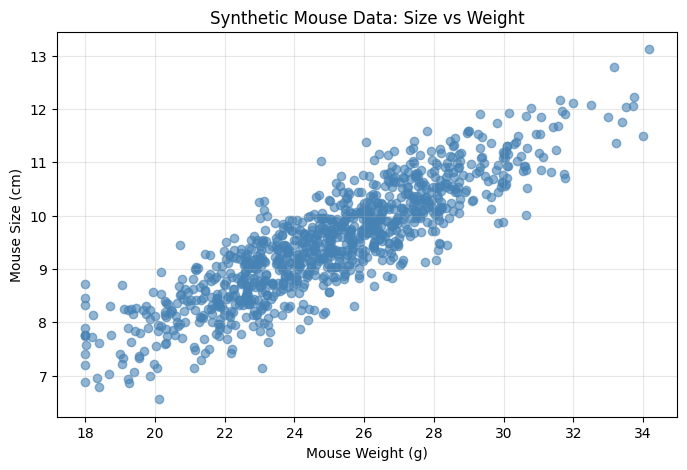

In [3]:
# Create DataFrame
df = pd.DataFrame({"weight_g": weight, "size_cm": size})

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df["weight_g"], df["size_cm"], alpha=0.6, c="steelblue")
plt.xlabel("Mouse Weight (g)")
plt.ylabel("Mouse Size (cm)")
plt.title("Synthetic Mouse Data: Size vs Weight")
plt.grid(True, alpha=0.3)
plt.show()

The data looks evenly distributed. From the quick look we can say the mouse size is increasing with the increase in mouse weight.

## Gradient Descent:
Calculate Partial derivatives against 'b' and 'm' to figure out how much each effects when changed. Using the partial derivative we will update values of 'b' and 'm'.

$$\partial_{MSE}/{\partial_{b}}  = -2/n \sum{}(y - \hat{y})$$


$$\partial_{MSE}/{\partial_{m}}  = -2/n \sum{} x (y - \hat{y})$$

In [4]:
def compute_gradient(n, x: pd.Series, y: pd.Series, y_pred: pd.Series):
    # calculate partial derivatives for b and m using the MSE loss function
    error = y - y_pred
    b_par = -2 / n * error.sum()
    m_par = -2 / n * (error * x).sum()

    return b_par, m_par

In [5]:
compute_gradient(len(df), df["weight_g"], df["size_cm"], 0 * df["weight_g"] + 0)

(np.float64(-18.975618183810877), np.float64(-479.5208037445761))

## Training Loop

Iteration 0: Loss=91.1012, Slope=0.0000, Intercept=0.0000
Iteration 10: Loss=6.3324, Slope=0.2807, Intercept=0.0111
Iteration 20: Loss=0.7053, Slope=0.3530, Intercept=0.0140
Iteration 30: Loss=0.3318, Slope=0.3716, Intercept=0.0148
Iteration 40: Loss=0.3070, Slope=0.3764, Intercept=0.0151
Model Converged at iteration 47.
Iteration 47: Loss=0.3055, Slope=0.3774, Intercept=0.0151


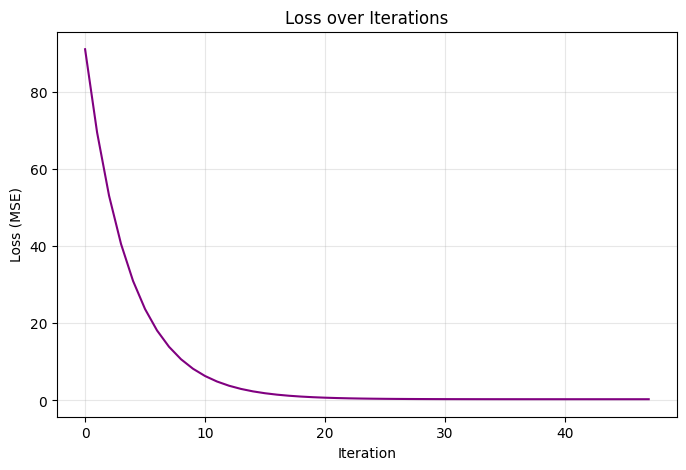

Final slope (m):     0.3774
Final intercept (b): 0.0151
Equation: size = 0.3774 × weight + (0.0151)


In [6]:
m = 0.0  # initial slope
b = 0.0  # initial intercept
learning_rate = 0.0001
x = df["weight_g"]
y = df["size_cm"]

iterations = 1000

losses = []
prev_loss = float("inf")  # Initialize previous loss to infinity for the first iteration
for i in range(iterations):
    y_pred = m * x + b
    # for linear regression, we can use mean squared error method as the loss function
    loss = np.mean((y - y_pred) ** 2)
    losses.append(loss)
    b_par, m_par = compute_gradient(len(df), x, y, y_pred)
    if i % 10 == 0:
        print(f"Iteration {i}: Loss={loss:.4f}, Slope={m:.4f}, Intercept={b:.4f}")

    # Check for convergence (optional)
    if (
        prev_loss - loss < 0.0001
    ):  # If the improvement is less than a small threshold, we can stop early
        print(f"Model Converged at iteration {i}.")
        print(f"Iteration {i}: Loss={loss:.4f}, Slope={m:.4f}, Intercept={b:.4f}")
        break
    prev_loss = loss

    # update parameters
    m -= learning_rate * m_par
    b -= learning_rate * b_par

# plot the losses over iterations
plt.figure(figsize=(8, 5))
plt.plot(losses, color="purple")
plt.xlabel("Iteration")
plt.ylabel("Loss (MSE)")
plt.title("Loss over Iterations")
plt.grid(True, alpha=0.3)
plt.show()

# After training converges:
print(f"Final slope (m):     {m:.4f}")
print(f"Final intercept (b): {b:.4f}")
print(f"Equation: size = {m:.4f} × weight + ({b:.4f})")

## Draw the best fitted line on data

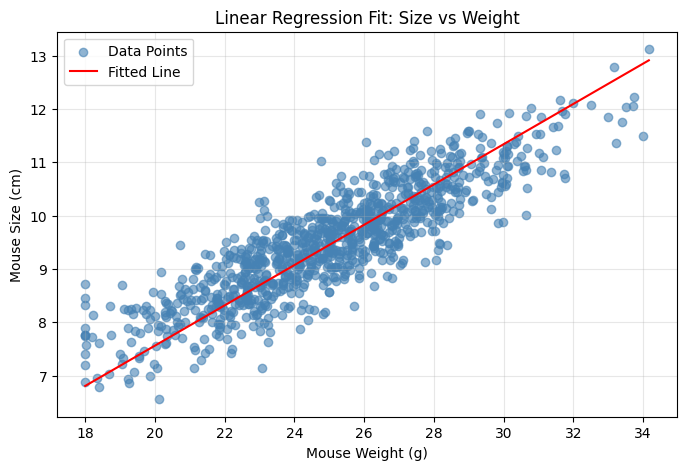

In [7]:
# Draw the best fitted line on data
plt.figure(figsize=(8, 5))
plt.scatter(
    df["weight_g"], df["size_cm"], alpha=0.6, c="steelblue", label="Data Points"
)
x_line = np.linspace(df["weight_g"].min(), df["weight_g"].max(), 100)
fitted_line = m * x_line + b
plt.plot(x_line, fitted_line, color="red", label="Fitted Line")
plt.xlabel("Mouse Weight (g)")
plt.ylabel("Mouse Size (cm)")
plt.title("Linear Regression Fit: Size vs Weight")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Calculate the final MSE

In [8]:
final_y_pred = m * x + b

print(f"Manual Linear Regression Coefficients:")
print(f"  Slope (m):     {m:.4f}")
print(f"  Intercept (b): {b:.4f}")
print(f"Equation: size = {m:.4f} × weight + ({b:.4f})")
print(f"MSE: {np.mean((y - final_y_pred) ** 2):.4f}")

Manual Linear Regression Coefficients:
  Slope (m):     0.3774
  Intercept (b): 0.0151
Equation: size = 0.3774 × weight + (0.0151)
MSE: 0.3055


## Compare with SKLearn

In [9]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(x.values.reshape(-1, 1), y)
print(f"Sklearn Linear Regression Coefficients:")
print(f"  Slope (m):     {reg.coef_[0]:.4f}")
print(f"  Intercept (b): {reg.intercept_:.4f}")
print(f"Equation: size = {reg.coef_[0]:.4f} × weight + ({reg.intercept_:.4f})")
print("MSE:", np.mean((y - reg.predict(x.values.reshape(-1, 1))) ** 2))

Sklearn Linear Regression Coefficients:
  Slope (m):     0.3048
  Intercept (b): 1.8716
Equation: size = 0.3048 × weight + (1.8716)
MSE: 0.25684643800665663


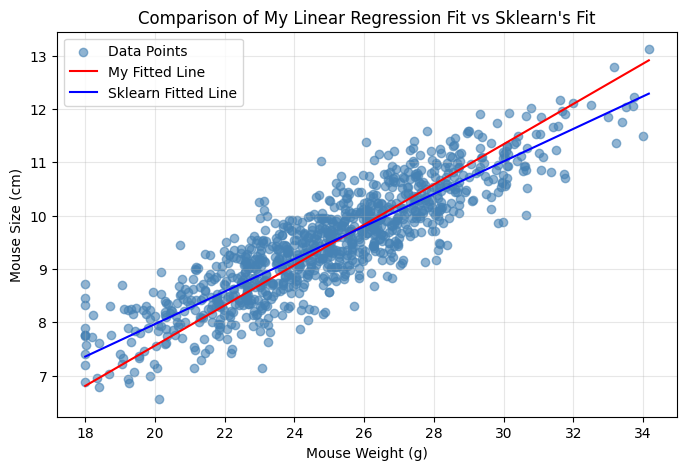

In [10]:
# Draw the my best fitted line and sklearn best fitted line on data
plt.figure(figsize=(8, 5))
plt.scatter(
    df["weight_g"], df["size_cm"], alpha=0.6, c="steelblue", label="Data Points"
)
x_line = np.linspace(df["weight_g"].min(), df["weight_g"].max(), 100)
my_fitted_line = m * x_line + b
sklearn_fitted_line = reg.coef_[0] * x_line + reg.intercept_
plt.plot(x_line, my_fitted_line, color="red", label="My Fitted Line")
plt.plot(x_line, sklearn_fitted_line, color="blue", label="Sklearn Fitted Line")
plt.xlabel("Mouse Weight (g)")
plt.ylabel("Mouse Size (cm)")
plt.title("Comparison of My Linear Regression Fit vs Sklearn's Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()